# Religion Timeseries Analysis

In [16]:
# Import statements

import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Utility Cells

### Basic class structure

Sample data:
```
{
  "year": 2010,
  "region": "North America",
  "country": "All Countries",
  "buddhists": 1.1,
  "christians": 77.4,
  "folk": 1,
  "hindus": 1,
  "jews": 1.8,
  "muslims": 1,
  "other": 1,
  "unaffiliated": 17.1
}

Below creating a class to store the basic data

In [17]:
class ReligionData:
    def __init__(self, year, region, country, buddhists, christians, folk,
                 hindus, jews, muslims, other, unaffiliated):
        self.year = year
        self.region = region
        self.country = country
        self.buddhists = buddhists
        self.christians = christians
        self.folk = folk
        self.hindus = hindus
        self.jews = jews
        self.muslims = muslims
        self.other = other
        self.unaffiliated = unaffiliated

    def __str__(self):
        return (f"{self.year}, {self.region}, {self.country}, {self.buddhists}, "
                f"{self.christians}, {self.folk}, {self.hindus}, "
                f"{self.jews}, {self.muslims}, {self.other}, "
                f"{self.unaffiliated}")

### Getting data from Github repository (API)

In [18]:
def get_data():
    file_url = 'https://raw.github.com/anrecdsousa/python/main/religion2'
    response = requests.get(file_url)
    response.raise_for_status()
    json_data = json.loads(response.text)

    religion_data_list = [ReligionData(**item) for item in json_data]

    return religion_data_list

### Data Functions

Helper functions to call and output either charts or tables
1. Data table by religion
2. Histogram
3. Scatter plot
4. Stacked bar chart
5. Grouped bar chart 
6. Variance chart

In [19]:
def filter_and_display_data(data_list, region):
    # Define the years to include
    years = [2010, 2020, 2030, 2040, 2050]

    # Convert the list of ReligionData objects to a list of dictionaries
    data_dicts = [vars(d) for d in data_list if d.year in years and d.region == region and d.country == "All Countries"]

    # Create a DataFrame from the list of dictionaries
    df = pd.DataFrame(data_dicts)

    # Print the title
    print(f"Religion Data for {region} for the years {', '.join(map(str, years))}")

    # Print the DataFrame to_string() output
    # Set max rows and max columns to None to display all data without truncation
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    print(df.to_string(index=False))
    print("\n")

def histogram_religion_percentage(data_list, region, year, religion):

    data_dicts = [vars(d) for d in data_list if d.year == year and d.region == region]
    xs = [d[f'{religion}'] for d in data_dicts]


    # Create a histogram of the Christian percentages
    plt.hist(xs, bins=10, edgecolor='black', alpha=0.7)
    plt.title(f'Histogram of {religion} Percentages in {region} - {year}')
    plt.xlabel(f'{religion} Percentage')
    plt.ylabel('# Countries')
    plt.grid(axis='y', alpha=0.75)
    plt.rcParams["figure.figsize"] = [7.50, 3.50]
    plt.rcParams["figure.autolayout"] = True
    plt.show()

def scatter_religion_percentage_over_years(data_list, country, religion):
    # Filter data for the specified country
    data_dicts = [vars(d) for d in data_list if d.country == country]
    xs = [d[f'{religion}'] for d in data_dicts]
    ys = [d['year'] for d in data_dicts]

    # Calculate the trend line
    z = np.polyfit(ys, xs, 1)  # 1 for linear (first-degree polynomial)
    p = np.poly1d(z)  # Creates a polynomial function with the fitted parameters

    # Create a scatter plot
    plt.scatter(ys, xs, alpha=0.5)

    # Plot the trend line
    plt.plot(ys, p(ys), "r--")  # "r--" indicates a red dashed line

    # Set the size of the figure
    plt.rcParams["figure.figsize"] = [7.50, 3.50]
    plt.rcParams["figure.autolayout"] = True

    # Add title and labels
    plt.title(f'{religion} percentage in {country} over years')
    plt.xlabel('Year')
    plt.ylabel('Percentage')

    # Show the plot
    plt.show()
    
def stacked_bar_chart(data_list, countries, year):
    # Define the religions to be included in the stack
    religions = ['buddhists', 'christians', 'folk', 'hindus', 'jews', 'muslims', 'other', 'unaffiliated']

    # Filter data for the specified year
    year_data = [d for d in data_list if d.year == year]

    # Initialize a dictionary to hold percentage breakdown by country
    country_breakdown = {country: {religion: 0 for religion in religions} for country in countries}

    # Populate the breakdown dictionary with the data
    for data in year_data:
        if data.country in countries:
            for religion in religions:
                country_breakdown[data.country][religion] += getattr(data, religion)

    # Prepare data for the stacked bar chart
    bar_width = 0.35
    indices = range(len(countries))

    # Create the base of the stacked bar with the first religion
    bottom = [0] * len(countries)
    for i, religion in enumerate(religions):
        values = [country_breakdown[country][religion] for country in countries]
        plt.bar(indices, values, bar_width, label=religion.capitalize(), bottom=bottom)
        # Update the bottom position for the next stack
        bottom = [values[i] + bottom[i] for i in range(len(bottom))]

    # Add labels, title, and legend
    plt.xlabel('Country')
    plt.ylabel('Percentage')
    plt.title(f'Stacked Bar Chart of Religions in {year}')
    plt.xticks(indices, countries)
    plt.rcParams["figure.figsize"] = [7.50, 3.50]
    plt.rcParams["figure.autolayout"] = True
    plt.legend()

    # Show the plot
    plt.tight_layout()
    plt.show()

def grouped_bar_chart(data_list, region, country, years, religions):
    # Number of bars for each group
    n_bars = len(religions)

    # Data to plot (each religion is a list of percentages, one for each year)
    percentages = {religion: [] for religion in religions}

    # Extract percentages for each religion and year
    for year in years:
        year_data = [d for d in data_list if d.year == year and d.country == country and d.region == region]
        for religion in religions:
            # Assuming there is one entry per religion per year
            if year_data:
                percentages[religion].append(getattr(year_data[0], religion))
            else:
                percentages[religion].append(0)  # Append 0 if no data for that year

    # Create figure and axis
    fig, ax = plt.subplots()

    # Set the positions of the bars on the x-axis
    indices = range(len(years))
    width = 0.85 / n_bars  # the width of the bars

    # Generate the bars for each religion
    for i, religion in enumerate(religions):
        # Calculate the x position for each bar
        pos = [x + (i * width) for x in indices]
        # Plot the bars
        plt.bar(pos, percentages[religion], width, label=religion.capitalize())

    # Add labels, title, and legend
    plt.xlabel('Year')
    plt.ylabel('Percentage')
    plt.title(f'Bar Chart of Religions in {country} over years')
    ax.set_xticks([x + (width * (n_bars / 2)) - (width / 2) for x in indices])
    ax.set_xticklabels(years)
    plt.legend()

    # Show the plot
    plt.tight_layout()
    plt.show()
    
def religion_variance_over_time(data_list, country, religion):
    # Filter the data for the specified country and religion
    data_dicts = [vars(d) for d in data_list if d.country == country]
    xs = [d[f'{religion}'] for d in data_dicts]

    # Extract the percentages and years
    years = [2010, 2020, 2030, 2040, 2050]

    # Calculate variances between consecutive years
    variances = [(xs[n] - xs[n-1]) / xs[n-1] * 100 for n in range(1, len(xs))]
    # Adjust the years to match the variance calculation (starting from the second year)
    variance_years = years[1:]

    # Create a bar chart
    plt.bar(variance_years, variances, color='skyblue')

    # Add labels and title
    plt.xlabel('Year')
    plt.ylabel(f'{religion} Variance (%)')
    plt.title(f'{religion} Variance over Years in {country}')

    # Optionally, format the y-axis labels to show them as percentages
    plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter())

    # Show the plot
    plt.show()

## Main function

Religion Data for Europe for the years 2010, 2020, 2030, 2040, 2050
 year region       country  buddhists  christians  folk  hindus  jews  muslims  other  unaffiliated
 2010 Europe All Countries          1        74.5     1       1     1      5.9      1          18.8
 2020 Europe All Countries          1        72.2     1       1     1      6.8      1          20.0
 2030 Europe All Countries          1        69.9     1       1     1      7.8      1          21.2
 2040 Europe All Countries          1        67.5     1       1     1      9.0      1          22.3
 2050 Europe All Countries          1        65.2     1       1     1     10.2      1          23.3




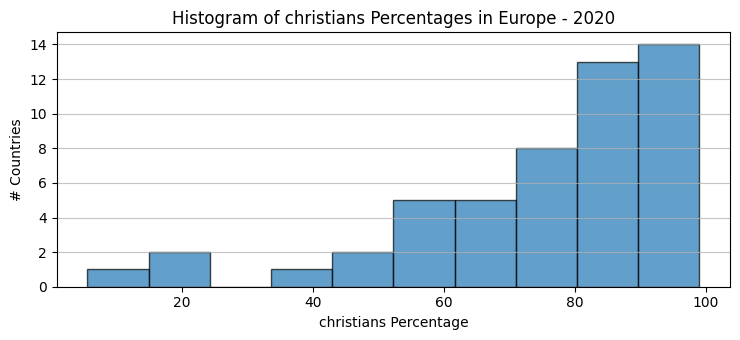

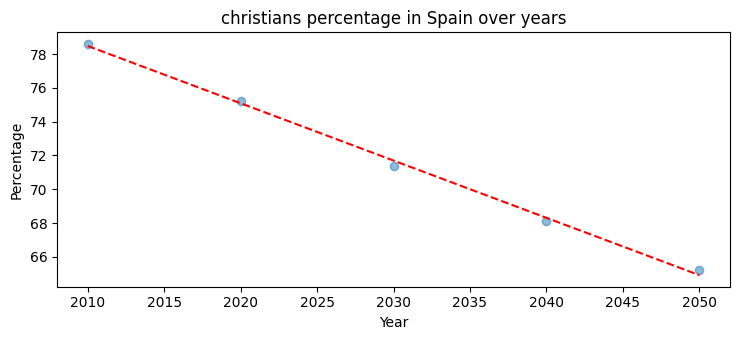

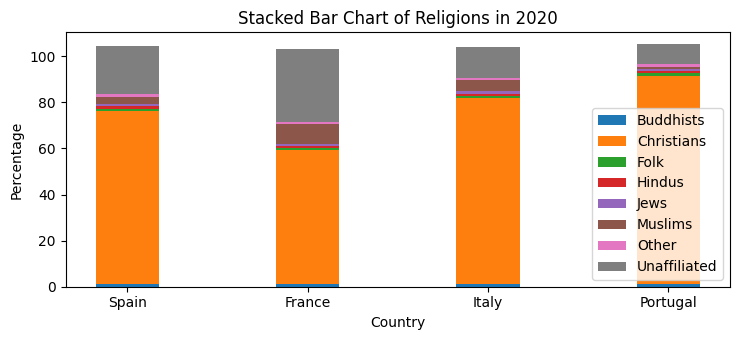

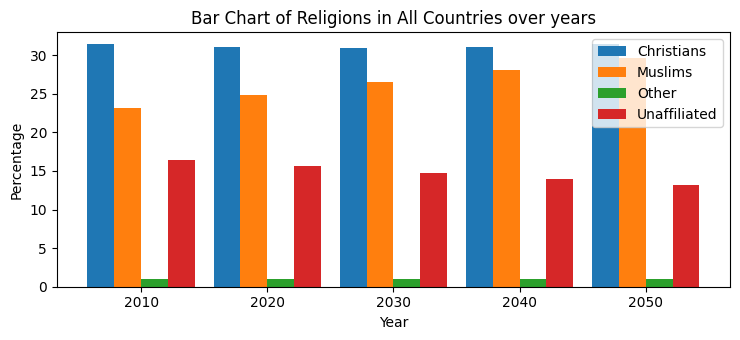

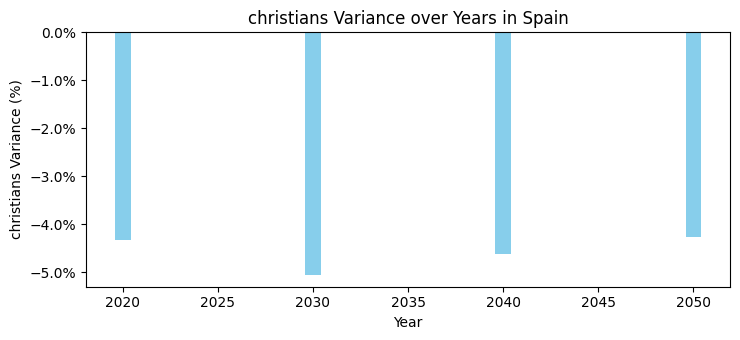

In [22]:
# get the data to be used by the utility functions
data_list = get_data()

# call each functiona and pass in the required parameters
filter_and_display_data(data_list,"Europe")
histogram_religion_percentage(data_list, "Europe", 2020, "christians")
scatter_religion_percentage_over_years(data_list,"Spain", "christians")
stacked_bar_chart(data_list, ['Spain', 'France', 'Italy', 'Portugal'], 2020)
grouped_bar_chart(data_list, "World", 'All Countries', [2010, 2020, 2030, 2040, 2050], ['christians', 'muslims', 'other', 'unaffiliated'])
religion_variance_over_time(data_list, "Spain","christians")
